In [25]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


############
# parameters
############

N_arr = np.arange(2, 51, 1)
nc = 80
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, 2*np.pi, 0.0001)

#############################
# Central-Spin Hamiltonian
#############################

def central_spin_chain(N, nb, ω, ω0, g):
   
# ======== Collective Battery operators ============

    JpB = qt.jmat(N / 2, '+')
    JmB = qt.jmat(N / 2, '-')
    JzB = qt.jmat(N / 2, 'z')

# ======== Collective Charger operators ============

    JpC = qt.jmat(nc / 2, '+')
    JmC = qt.jmat(nc / 2, '-')
    JzC = qt.jmat(nc / 2, 'z')
    
# ======== Identities =================

    IC = qt.qeye(nc+1)
    IB = qt.qeye(N+1)
    I_full = qt.tensor(IB, IC)

# ======== Embedded operators into full space =============

# ====== Battery operators ==========

    JpB_full = qt.tensor(JpB, IC)
    JmB_full = qt.tensor(JmB, IC)
    JzB_full = qt.tensor(JzB, IC)

# ===== Charger operators ===========

    JpC_full = qt.tensor(IB, JpC)
    JmC_full = qt.tensor(IB, JmC)
    JzC_full = qt.tensor(IB, JzC)

# ======== Battery Hamiltonian =============

    HB = ω0 * (JzB_full + 0.5 * N * I_full)
    
# ======== Charger Hamiltonian =============

    HC = ω * (JzC_full + 0.5 * nc * I_full)

# ======== Interaction Hamiltonian ===========

    Hint = g * (JpB_full * JmC_full + JmB_full * JpC_full)
    
# ======== Total Hamiltonian =====================

    H = HB + HC + Hint

# ======= Battery-only Hamiltonian ==============


    HB_local = ω * (JzB + 0.5 * N * IB)

    return H, HB, HB_local


###################
# Initial state
###################

def initial_state(N, nc):

# ========= Battery state: all spins DOWN (ground) ================
    
    psiB = qt.basis(N+1, N)

# ========= Charger state: all spins UP (excited) ==================
    
    psiC = qt.basis(nc+1, 0)

    return qt.tensor(psiB, psiC)


N= 2, τ=0.1281, Eb=1.719325, Ergotropy=1.559574, erg/Eb=0.907084842019 Variance=1.0496477512e+00
N= 3, τ=0.1197, Eb=2.524498, Ergotropy=2.308438, erg/Eb=0.914414742679 Variance=1.7997717951e+00
N= 4, τ=0.1138, Eb=3.333626, Ergotropy=3.069846, erg/Eb=0.920872727401 Variance=2.5949681787e+00
N= 5, τ=0.1092, Eb=4.145367, Ergotropy=3.839450, erg/Eb=0.926202697663 Variance=3.4382837560e+00
N= 6, τ=0.1055, Eb=4.960058, Ergotropy=4.616901, erg/Eb=0.930815861512 Variance=4.3270056480e+00
N= 7, τ=0.1023, Eb=5.775137, Ergotropy=5.398877, erg/Eb=0.934848271204 Variance=5.2742736867e+00
N= 8, τ=0.0996, Eb=6.592163, Ergotropy=6.186337, erg/Eb=0.938438215621 Variance=6.2678486454e+00
N= 9, τ=0.0972, Eb=7.409608, Ergotropy=6.977378, erg/Eb=0.941666267802 Variance=7.3191809916e+00
N=10, τ=0.0950, Eb=8.227477, Ergotropy=7.771877, erg/Eb=0.944624670438 Variance=8.4370458527e+00
N=11, τ=0.0931, Eb=9.046552, Ergotropy=8.569521, erg/Eb=0.947269252472 Variance=9.5957833107e+00
N=12, τ=0.0914, Eb=9.866008, E

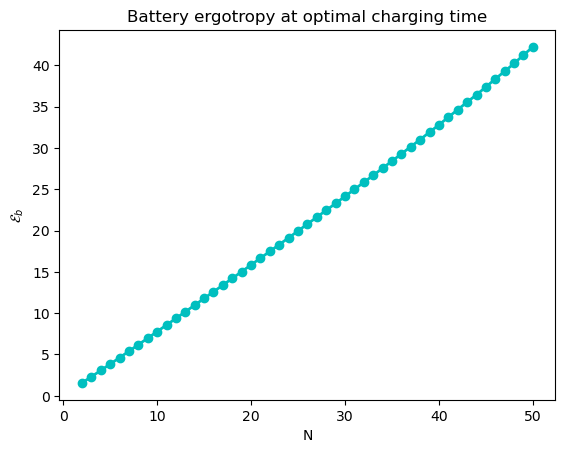

In [26]:
#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB, HB_local = central_spin_chain(N, nc, ω, ω0, g)
    
    psi0 = initial_state(N, nc)

    opts = qt.Options(atol=1e-16, rtol=1e-14)        ## ODE solver options
    
    res = qt.sesolve(H, psi0, tlist, e_ops=HB, options=opts)
    
    EB = np.array(res.expect[0])
    
    power = EB / tlist

    τ = tlist[np.argmax(power)]
    
    τ_list.append(τ)

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio = [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB, HB_local = central_spin_chain(N, nc, ω, ω0, g)
    
    psi0 = initial_state(N, nc)
    
    res = qt.sesolve(H, psi0, [0, τ], options=opts)
    
    rho_b = res.states[-1].ptrace(0)
    
    r_vals, r_vecs = rho_b.eigenstates()

    # Clip numerical noise to prevent negative probabilities
    r_vals = np.maximum(r_vals, 0) 
    # Renormalize 
    r_vals = r_vals / np.sum(r_vals)
    
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]
    
     # assign degenerate energies 
    e_vals = np.array([0] + [ω0]*N)
    
    # e_vals = np.arange(N + 1) * ω0
    
    E_B = qt.expect(HB_local, rho_b)
    
    E_erg = E_B - sum(r_vals[j]*e_vals[j] for j in range(len(r_vals)))

    W_2 = (qt.expect(HB_local**2, rho_b) + sum(r_vals[j]*(e_vals[j])**2 for j in range(len(r_vals)))) - 2 * sum(e_vals[i]*r_vals[i]*qt.expect(HB_local, r_vecs[i]) for i in range(len(r_vals)))
    
    ΔE2 = W_2 - (E_erg)**2
    
    ΔE = np.sqrt(ΔE2)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)


    print(f"N={N:2d}, τ={τ:.4f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f} Variance={ΔE2:.10e}")


###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("OP1")
plt.show()


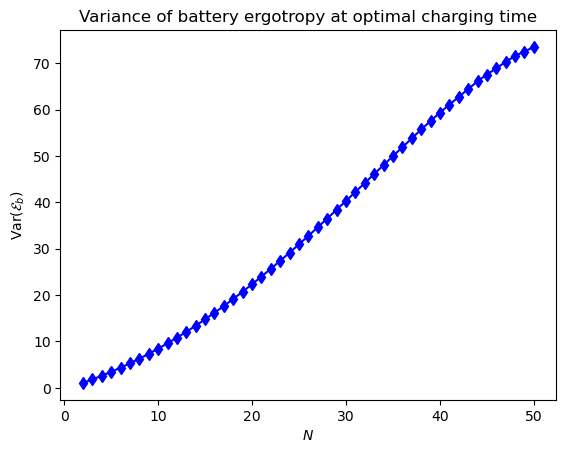

In [27]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
#plt.savefig("OP2")
plt.show()

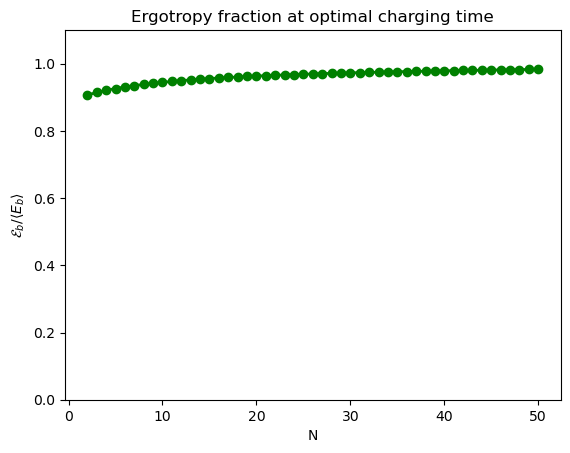

In [28]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
#plt.savefig("OP3")
plt.show()

N= 2, τ=0.1281, Relative Fluctuation =0.656925123484, Relative Fluctuation with Eb =0.595886821854
N= 3, τ=0.1197, Relative Fluctuation =0.581152924760, Relative Fluctuation with Eb =0.531414802151
N= 4, τ=0.1138, Relative Fluctuation =0.524746433911, Relative Fluctuation with Eb =0.483224679789
N= 5, τ=0.1092, Relative Fluctuation =0.482949644356, Relative Fluctuation with Eb =0.447309263438
N= 6, τ=0.1055, Relative Fluctuation =0.450550197079, Relative Fluctuation with Eb =0.419379269849
N= 7, τ=0.1023, Relative Fluctuation =0.425380796557, Relative Fluctuation with Eb =0.397666502264
N= 8, τ=0.0996, Relative Fluctuation =0.404692954890, Relative Fluctuation with Eb =0.379779334461
N= 9, τ=0.0972, Relative Fluctuation =0.387738572830, Relative Fluctuation with Eb =0.365120334760
N=10, τ=0.0950, Relative Fluctuation =0.373739729605, Relative Fluctuation with Eb =0.353043768908
N=11, τ=0.0931, Relative Fluctuation =0.361479501858, Relative Fluctuation with Eb =0.342418417509
N=12, τ=0.

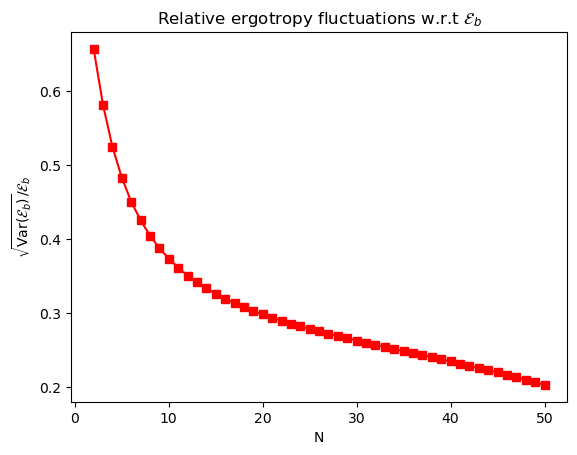

In [29]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={F_ratio[idx]:.12f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.12f}")


######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
#plt.savefig("OP4")
plt.show()

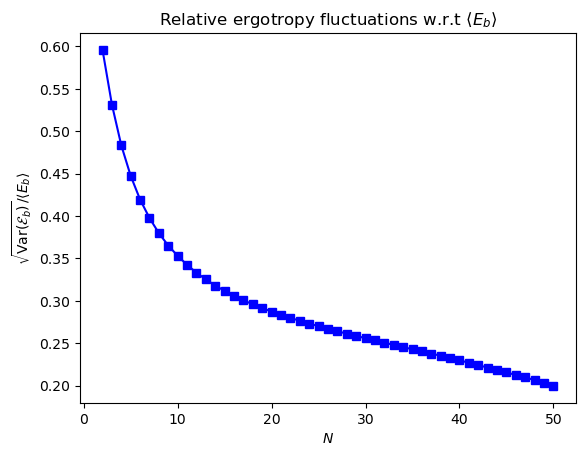

In [30]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
#plt.savefig("OP5")
plt.show()